# Practical Bayesian Modeling with PyMC

**Abstract**

In this tutorial, we explore Bayesian regression using PyMC -- the primary library for Bayesian sampling in Python -- focusing on survey data and other datasets with categorical outcomes. Starting with logistic regression, we’ll build up to categorical and ordered logistic regression, showcasing how Bayesian approaches provide versatile tools for developing and evaluating complex models. Participants will leave with practical skills for implementing Bayesian regression models in PyMC, along with a deeper appreciation for the power of Bayesian inference in real-world data analysis. Participants should be familiar with Python, the SciPy ecosystem, and basic statistics, but no experience with Bayesian methods is required.

**Description**

In this hands-on tutorial, we will dive into the world of Bayesian regression using PyMC, with a particular focus on datasets that feature categorical outcomes. PyMC provides versatile tools for iterative development of powerful models. This tutorial guides participants through the fundamentals of Bayesian regression, starting from logistic regression and extending to categorical and ordered logistic regression. It also introduces the PyMC package, its syntax and capabilities.

Outline:

* Logistic Regression with PyMC

  - Overview of Bayesian inference
  - Modeling binary outcomes with logistic regression
  - Introduction to PyMC and its capabilities
  - Hands-on example: Happiness data in the General Social Survey

* Categorical Regression

  - Extending logistic regression to multi-class outcomes
  - Differences between Bayesian models and GLM
  - Hands-on example: Political alignment and party affiliation (?)

* Ordered Logistic Regression
  - Introduction to ordinal outcomes and their challenges
  - Implementing ordered logistic regression in PyMC
  - Hands-on example: Political alignment and party affiliation (?)

* Conclusion and Q&A
  - Recap of key concepts
  - Resources for further learning
  - Open discussion and questions

*Who Should Attend:* This tutorial is aimed at data scientists who are comfortable with Python, the SciPy ecosystem, and basic statistics but are new to Bayesian statistics and/or PyMC. By the end of the session, participants will have hands-on experience with Bayesian regression models and a solid understanding of how to apply these techniques to real-world data analysis. 

Notes:
The material for the tutorial is in this repository:
https://github.com/AllenDowney/SurveyDataPyMC/tree/main/notebooks

The dataset from the General Social Survey (GSS) can be found here:
https://gssdataexplorer.norc.org/


[The slides for the tutorial are here](COMING SOON).

The plan:

```
Logistic regression
Example: happiness data?
Start with the DIY implementation
Show the version using LogisticRegression

Categorical regression
Example: political party?
Start with the version using Categorical
Develop the DIY version with Multinomial

Ordered logistic regression
Start with OrderedLogistic
Maybe develop the DIY version (or leave it in the notebook for future exploration)
```



[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/SurveyDataPyMC/blob/main/notebooks/01_logistic_regression.ipynb)

In [1]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
%load_ext autoreload
%autoreload 2

<IPython.core.display.Javascript object>

In [3]:
# Get utils.py

from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/SurveyDataPyMC/raw/main/notebooks/utils.py")

<IPython.core.display.Javascript object>

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

from utils import value_counts, decorate

<IPython.core.display.Javascript object>

In [5]:
# Make the figures smaller to save some screen real estate

plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

<IPython.core.display.Javascript object>

## Data

In [6]:

# This dataset is prepared in GssExtract/notebooks/02_make_extract-2022_3a.ipynb

DATA_PATH = "https://github.com/AllenDowney/GssExtract/raw/main/data/interim/"
filename = "gss_extract_2022_3a.hdf"
download(DATA_PATH + filename)

<IPython.core.display.Javascript object>

In [7]:
gss = pd.read_hdf(filename, "gss")
gss.columns

Index(['age', 'attend', 'ballot', 'class', 'clmtcaus', 'clmtusa', 'clmtwrld',
       'cohort', 'commun', 'conarmy', 'conbus', 'conclerg', 'coneduc',
       'confed', 'confinan', 'coninc', 'conjudge', 'conlabor', 'conlegis',
       'conmedic', 'conpress', 'conrinc', 'consci', 'contv', 'degree', 'educ',
       'eqwlth', 'fair', 'fear', 'fund', 'goodlife', 'hapmar', 'happy',
       'health', 'helpful', 'id', 'life', 'partyid', 'race', 'realinc',
       'realrinc', 'reg16', 'region', 'relig', 'relig16', 'reliten', 'res16',
       'rincome', 'satfin', 'satjob', 'sex', 'sexbirth', 'sexnow', 'srcbelt',
       'trust', 'wtssall', 'year'],
      dtype='object')

<IPython.core.display.Javascript object>

Generally speaking, would you say that most people can be trusted or that you can't be too careful in dealing with people?
	
```
1	Most people can be trusted
2	Can't be too careful
3	Depends
```

In [8]:
value_counts(gss["trust"])

,counts
values,
1.0,15783
2.0,24890
3.0,1966
NaN,29751


<IPython.core.display.Javascript object>

In [9]:
gss["y"] = gss["trust"].replace({1: 1, 2: 0, 3: np.nan})
value_counts(gss["y"])

,counts
values,
0.0,24890
1.0,15783
NaN,31717


<IPython.core.display.Javascript object>

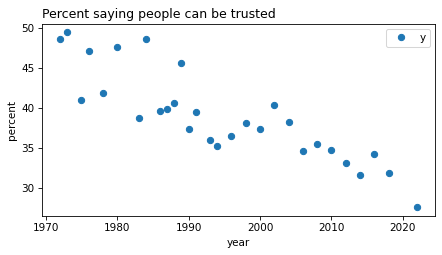

<IPython.core.display.Javascript object>

In [10]:
time_series = gss.groupby("year")["y"].mean() * 100
time_series.plot(style="o")
decorate(ylabel="percent", title="Percent saying people can be trusted")

Generally speaking, do you usually think of yourself as a Republican, Democrat, Independent, or what?

```
0	Strong democrat
1	Not very strong democrat	
2	Independent, close to democrat	
3	Independent (neither, no response)	
4	Independent, close to republican	
5	Not very strong republican	
6	Strong republican
7	Other party
```

In [241]:
party_map = {
    0: 0,
    1: 0,
    2: 1,
    3: 1,
    4: 1,
    5: 2,
    6: 2,
    7: np.nan,
}

gss["partyid3"] = gss["partyid"].replace(party_map)
value_counts(gss["partyid3"])

,counts
values,
0.0,25439
1.0,26705
2.0,18338
NaN,1908


<IPython.core.display.Javascript object>

In [242]:
party_names = {
    0: "Democrat",
    1: "Independent",
    2: "Republican",
}

table = (
    gss.pivot_table(index="year", columns="partyid3", values="y", aggfunc="mean") * 100
).rename(columns=party_names)

<IPython.core.display.Javascript object>

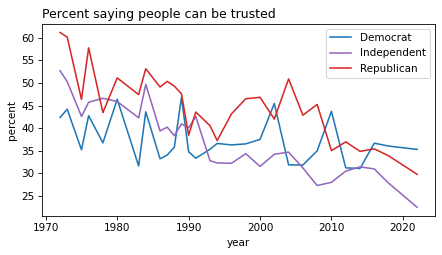

<IPython.core.display.Javascript object>

In [243]:
colors = ["C0", "C4", "C3"]
table.plot(color=colors)
decorate(ylabel="percent", title="Percent saying people can be trusted")

## Logistic Regression


In [203]:
data = gss.dropna(subset=["y", "year"])
data.shape

(40673, 59)

<IPython.core.display.Javascript object>

In [204]:
y = data["y"].values
year = data["year"].values

<IPython.core.display.Javascript object>

Shift `year` so it's centered at its mean.

In [205]:
year_shift = data["year"].mean()
year = year - year_shift

<IPython.core.display.Javascript object>

Here's the model.

In [206]:
with pm.Model() as logistic_model:
    # Priors for intercept and slope
    sigma_prior = 1
    alpha = pm.Normal("alpha", 0, sigma_prior)
    beta = pm.Normal("beta", 0, sigma_prior)

    # Linear predictor (log-odds)
    logits = alpha + beta * year

    # Bernoulli likelihood with logit link
    y_obs = pm.Bernoulli("y_obs", logit_p=logits, observed=y)

<IPython.core.display.Javascript object>

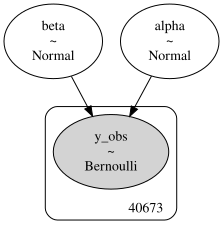

<IPython.core.display.Javascript object>

In [207]:
pm.model_to_graphviz(logistic_model)

In [208]:
with logistic_model:
    idata = pm.sample(500)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 22 seconds.


<IPython.core.display.Javascript object>

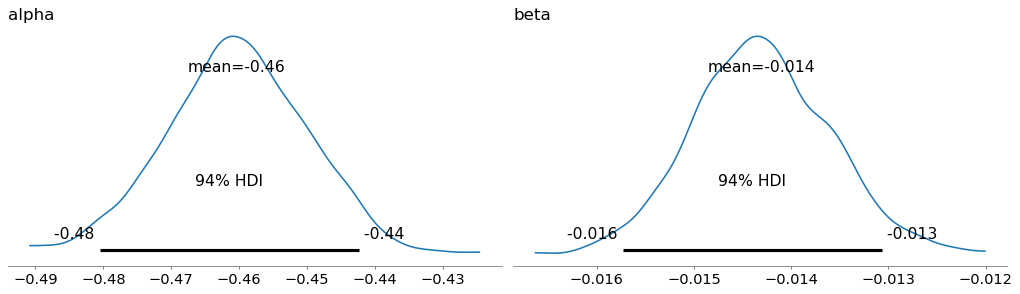

<IPython.core.display.Javascript object>

In [209]:
pm.plot_posterior(idata, var_names=["alpha", "beta"])
plt.tight_layout()

Looking at the posterior distributions of `alpha` and `beta`, we can see that they fall comfortably within the prior distributions of these parameters, which means that the priors didn't have much effect on the results.

As an experiment, try increasing or decreasing `sigma_prior` and see what effect it has on the posterior distributions.

After sampling, we want to check that the process worked well — meaning:

* All chains have effectively explored the posterior distribution, and

* Successive draws within each chain are only weakly correlated (each draw should provide mostly new information).

We can check these properties visually using plot_trace, which shows:

*    On the left, the distribution from each chain should look similar — this is evidence that the chains all converged to the same region of the posterior.

*    On the right, the sequence of draws within each chain should look like uncorrelated noise (sometimes called "hairy caterpillars"). It shouldn't look like a random walk and there should be flat spots, which would suggest the chain got stuck.

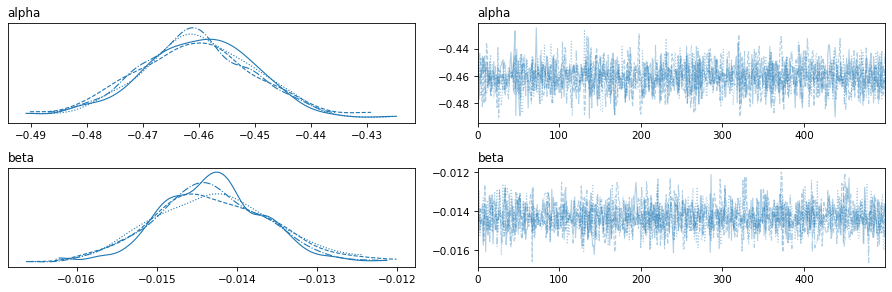

<IPython.core.display.Javascript object>

In [210]:
pm.plot_trace(idata, var_names=["alpha", "beta"])
plt.tight_layout()

To check these properties numerically, we can look at two key summary statistics: ESS and r-hat.

*    Effective Sample Size (ESS) tells us how much independent information the chains actually contribute. If successive values within a chain are highly correlated, the chain isn’t exploring the posterior efficiently, and ESS will be smaller than the total number of draws.

*    r-hat quantifies the difference between chains. If all chains converged to the same posterior distribution, r-hat should be close to 1. If the chains are exploring different regions, r-hat will be larger than 1, indicating failure to coverge.

In [211]:
pm.summary(idata, var_names=["alpha", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.460,0.010,-0.481,-0.442,0.0,0.0,1989.0,1543.0,1.00
beta,-0.014,0.001,-0.016,-0.013,0.0,0.0,1985.0,1476.0,1.01


<IPython.core.display.Javascript object>

### Interpreting the results

In [212]:
def get_sample(idata, var_name):
    """Extract a posterior sample from idata

    idata: InferenceData object
    var_name: string

    returns: NumPy array
    """
    return idata.posterior[var_name].stack(sample=["chain", "draw"])

<IPython.core.display.Javascript object>

In [213]:
# Collect posterior draws of alpha and beta
alphas = get_sample(idata, "alpha").values
betas = get_sample(idata, "beta").values
betas.shape

(2000,)

<IPython.core.display.Javascript object>

In [214]:
# Sample 100 from the posterior
idx = np.random.choice(len(alpha_samples), size=100, replace=False)
alpha_samples = alphas[idx]
beta_samples = betas[idx]
beta_samples.shape

(100,)

<IPython.core.display.Javascript object>

In [215]:
# Range of years to predict
year_range = np.arange(1970, 2031)
year_centered = year_range - year_shift

<IPython.core.display.Javascript object>

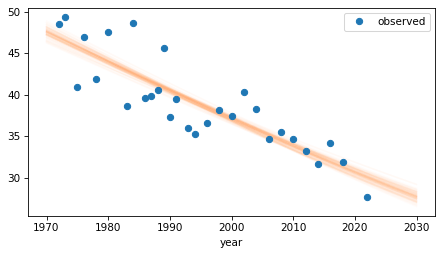

<IPython.core.display.Javascript object>

In [216]:
from scipy.special import expit

for alpha, beta in zip(alpha_samples, beta_samples):
    logits = alpha + beta * year_centered
    probs = expit(logits) * 100
    plt.plot(years, probs, color="C1", alpha=0.02)

time_series.plot(style="o", label="observed")
decorate()

### Centering

Because we centered `years`, the sampled slopes and intercepts are uncorrelated.

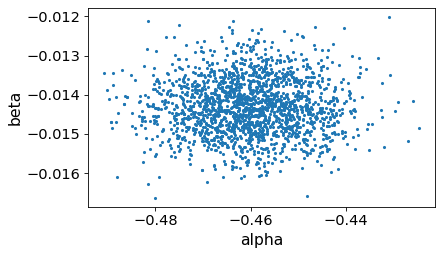

<IPython.core.display.Javascript object>

In [217]:
az.plot_pair(idata, var_names=["alpha", "beta"])
decorate()

As an experiment, try:

* Set `year_shift=1970` and run the model again. You might get some warnings from the sampler, and `plot_pair` will show that the alphas and betas are correlated. The not-quite-centered predictor stretches the shape of the joint posterior distribution and makes it harder to sample efficiently.

* Set `year_shift=0` and run the model again. With the predictor completely uncentered, the joint posterior distribution is so stretched that the sampler diverges frequently -- and basically fails.

Without centering, the intercept represents the log-odds of the outcome when `year=0`, which is way outside the range of the data.
This forces the intercept and slope to compensate for each other — if the slope increases, the intercept must decrease to hit the same observed points.

As a general rule, it's a good idea to center continuous predictors in Bayesian regression models.

## Categorical predictors

In [218]:
value_counts(gss["partyid3"])

,counts
values,
0.0,25439
1.0,26705
2.0,18338
NaN,1908


<IPython.core.display.Javascript object>

In [219]:
data = gss.dropna(subset=["y", "year", "partyid3"])
data.shape

(39697, 59)

<IPython.core.display.Javascript object>

In [220]:
y = data["y"].values
year = data["year"].values
year_shift = data["year"].mean()
year = year - year_shift

partyid3 = data["partyid3"].astype(int).values

with pm.Model() as logistic_model2:
    # Party-specific intercepts (one for each party)
    sigma_prior = 1
    alpha = pm.Normal("alpha", 0, sigma_prior, shape=3)

    # Shared slope for year (assuming effect of year is the same across parties)
    beta = pm.Normal("beta", 0, sigma_prior)

    # Linear predictor (log-odds)
    logits = alpha[partyid3] + beta * year

    # Bernoulli likelihood with logit link
    y_obs = pm.Bernoulli("y_obs", logit_p=logits, observed=y)

<IPython.core.display.Javascript object>

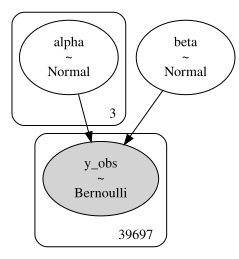

<IPython.core.display.Javascript object>

In [221]:
pm.model_to_graphviz(logistic_model2)

In [222]:
with logistic_model2:
    idata2 = pm.sample(500)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 39 seconds.


<IPython.core.display.Javascript object>

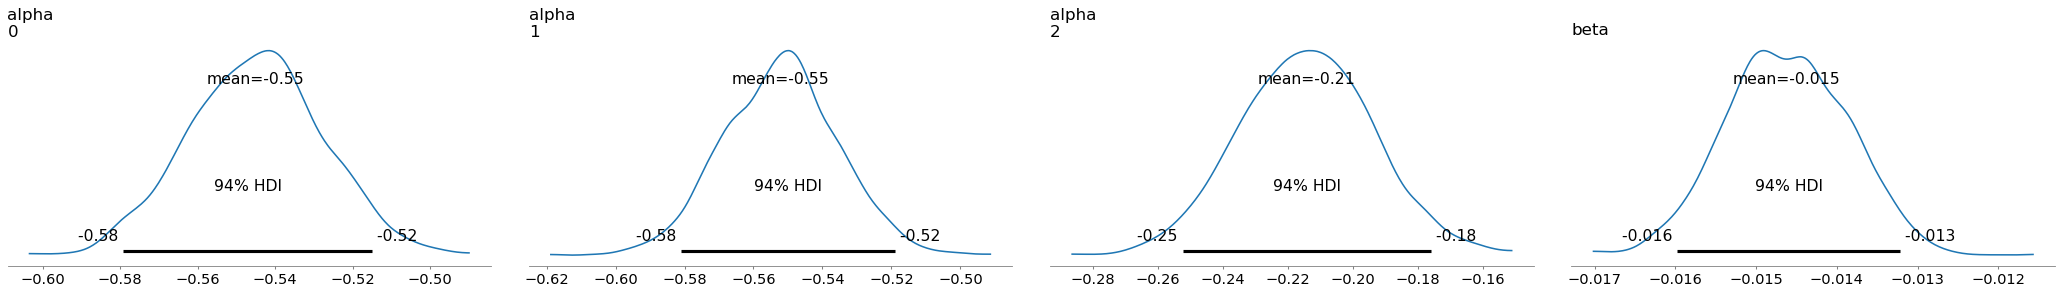

<IPython.core.display.Javascript object>

In [223]:
pm.plot_posterior(idata2)
plt.tight_layout()

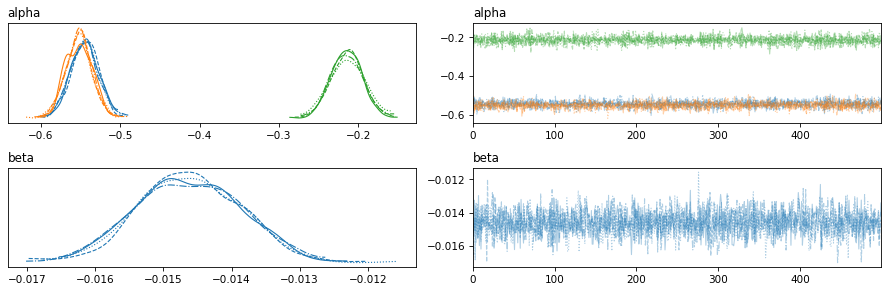

<IPython.core.display.Javascript object>

In [224]:
pm.plot_trace(idata2)
plt.tight_layout()

In [225]:
pm.summary(idata2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],-0.545,0.017,-0.579,-0.515,0.0,0.0,3573.0,1770.0,1.0
alpha[1],-0.552,0.017,-0.581,-0.519,0.0,0.0,2981.0,1701.0,1.0
alpha[2],-0.214,0.020,-0.252,-0.176,0.0,0.0,3736.0,1369.0,1.0
beta,-0.015,0.001,-0.016,-0.013,0.0,0.0,3289.0,1527.0,1.0


<IPython.core.display.Javascript object>

### Plotting the results

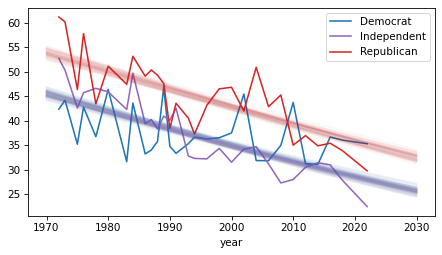

<IPython.core.display.Javascript object>

In [247]:
alphas = get_sample(idata2, "alpha").values
alphas.shape

betas = get_sample(idata2, "beta").values
betas.shape

idx = np.random.choice(len(beta_samples), size=100, replace=False)
alpha_samples = alphas[:, idx]
alpha_samples.shape

beta_samples = betas[idx]
beta_samples.shape

# Range of years to predict
year_range = np.arange(1970, 2031)
year_centered = year_range - year_shift


parties = ["Democrat", "Independent", "Republican"]
colors = ["C0", "C4", "C3"]
table.plot(color=colors)

for i, party_name in enumerate(parties):
    for alpha, beta in zip(alpha_samples[i], beta_samples):
        logits = alpha + beta * year_centered
        probs = expit(logits) * 100
        plt.plot(year_range, probs, color=colors[i], alpha=0.02)

decorate()